# Score de complexité (variance et entropie)


In [1]:
from fastai.vision.all import *

In [1]:
# Import d'une image de chat sur fond bleu
!wget -q --user-agent="Mozilla/5.0" -O chat_bgBLEU.jpg "https://images.unsplash.com/photo-1574158622682-e40e69881006?q=80&w=1000&auto=format&fit=crop"
!wget -q --user-agent="Mozilla/5.0" -O chatNOIR_bgBLANC.jpg "https://media.istockphoto.com/id/1359216701/photo/funny-black-cat-portrait-looking-shocked.jpg?s=612x612&w=0&k=20&c=vF9_rw4cZOIHJMzjBw5mQ7t7a5GhVeB7-auJJxmC20w="
!wget -q --user-agent="Mozilla/5.0" -O chatBENGAL_bgBLANC.jpg "https://amicidicasa.it/wp-content/uploads/2018/09/bengal-standard12.jpg"
!wget -q --user-agent="Mozilla/5.0" -O chatBENGAL_bg.jpg "https://consumer-cms.petfinder.com/sites/default/files/images/content/Bengal%202.jpg"
!wget -q --user-agent="Mozilla/5.0" -O chat_fond.jpg "https://lh4.googleusercontent.com/proxy/OLfiXDuaVyi5KLGSKwlgnShEgAWOwoLAHIYc59LLYtORxY46jaTQrRbDQhGNOt7RZtqd4AMRX7zq3sQ39Ppd75SaVQEw"

!wget -q --user-agent="Mozilla/5.0" -O dog_bgBLANC.jpg "https://media.istockphoto.com/id/149325740/photo/belgian-shepherd-dog-puppy-5-months-old-standing.jpg?s=612x612&w=0&k=20&c=4acZXWtBRma9S4Kxr2BZL-NSTXHdQwI9VqWxfmzJTmQ="
!wget -q --user-agent="Mozilla/5.0" -O dogBRUN_bg.jpg "https://dogdaycareivybridge.co.uk/wp-content/uploads/2024/11/Dog-Soft-Play-Ivybridge-Dog-Looking-at-Camera-Pugs-and-Pals-Devon-Ltd.jpg"


!wget -q --user-agent="Mozilla/5.0" -O medical_hand.jpg "https://www.visiblebody.com/hs-fs/hubfs/Medical_X-Ray_imaging_JUP05_nevit.jpg?width=515&height=688&name=Medical_X-Ray_imaging_JUP05_nevit.jpg"

# Récupération des paths
import glob
mes_images = glob.glob("./*.jpg")
print("Liste de paths d'images \n", mes_images)

from torchvision.io import read_image
img_tensor = read_image("dogBRUN_bg.jpg")

print(img_tensor.shape)

Liste de paths d'images 
 ['./chat_bgBLEU.jpg', './chatNOIR_bgBLANC.jpg', './chatBENGAL_bgBLANC.jpg', './chatBENGAL_bg.jpg', './chat_fond.jpg', './dog_bgBLANC.jpg', './dogBRUN_bg.jpg', './medical_hand.jpg']
torch.Size([3, 600, 1000])


torch.Size([3, 600, 1000])


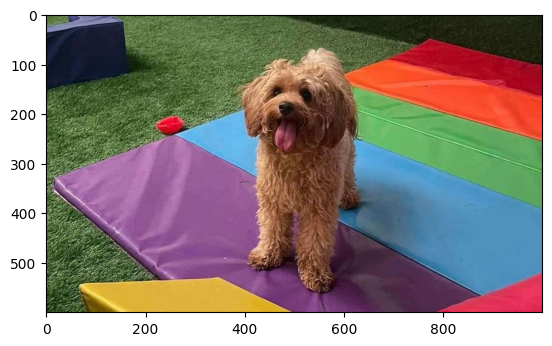

In [2]:
# Affichage de l'image
import matplotlib.pyplot as plt
plt.imshow(img_tensor.permute(1,2,0))
print(img_tensor.shape)

torch.Size([500, 500])


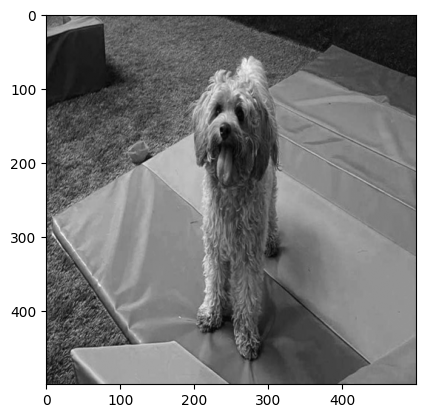

In [3]:
im = img_tensor

import torchvision.transforms.functional as F

# On redimensionne en [500, 500]
im = F.resize(im, [500, 500], antialias=True)

# On convertit en float, on fait la moyenne sur la dimension des canaux (dim=0)
im_gray = im.float().mean(dim=0)

# Matplotlib gère très bien les flottants pour l'affichage
plt.imshow(im_gray, cmap='gray')
print(im_gray.shape)

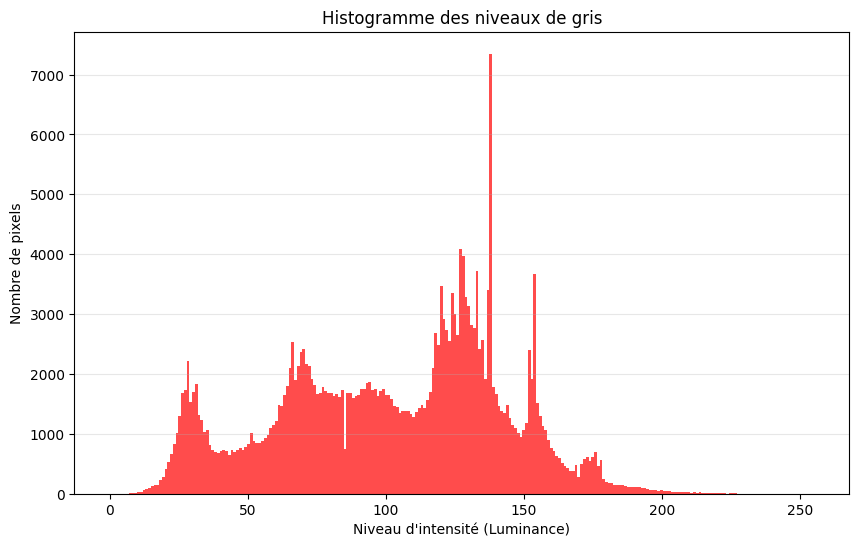

In [4]:
# 1. On aplatit le tenseur pour passer de (1000, 1000) à (1 000 000,)
pixels = im_gray.flatten()

# 2. Création de l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(pixels, bins=256, range=(0, 255), color='red', alpha=0.7)

plt.title("Histogramme des niveaux de gris")
plt.xlabel("Niveau d'intensité (Luminance)")
plt.ylabel("Nombre de pixels")
plt.grid(axis='y', alpha=0.3)
plt.show()

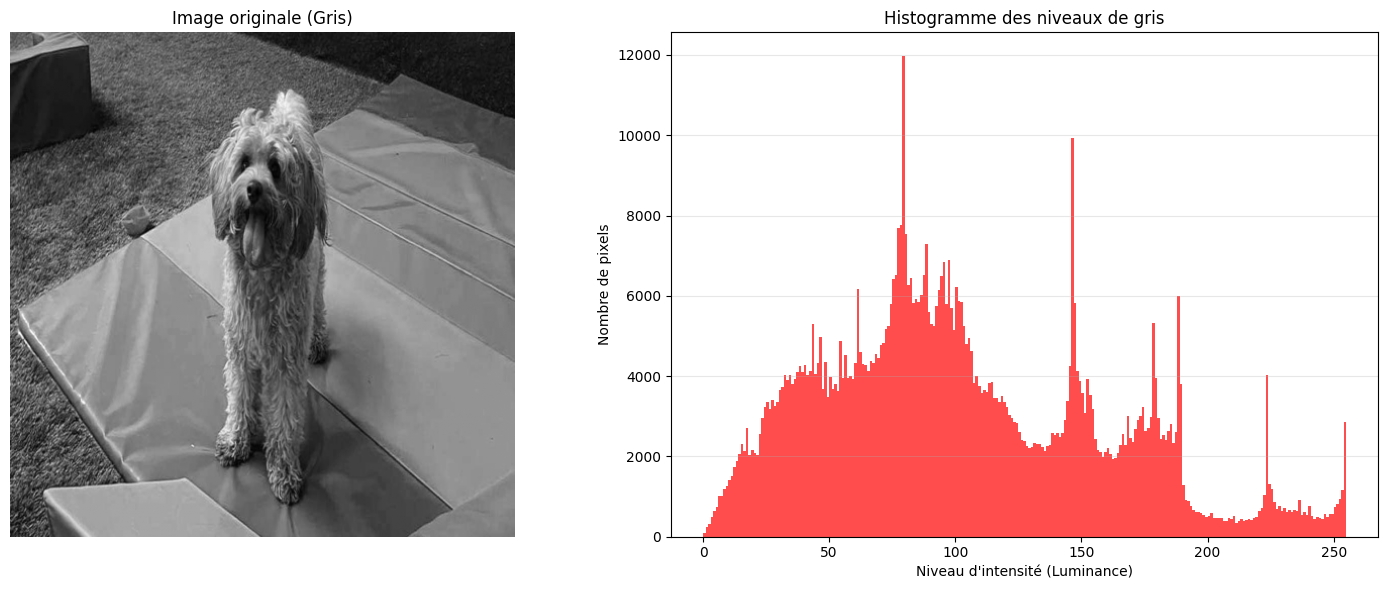

In [5]:
import matplotlib.pyplot as plt

# 1. Création de la figure avec 1 ligne et 2 colonnes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 2. Affichage de l'image sur le premier axe (ax1)
ax1.imshow(im_gray, cmap='gray')
ax1.set_title("Image originale (Gris)")
ax1.axis('off')  # Masque les coordonnées x/y pour l'image

# 3. Affichage de l'histogramme sur le second axe (ax2)
ax2.hist(im.flatten(), bins=255, range=(0, 255), color='red', alpha=0.7)
ax2.set_title("Histogramme des niveaux de gris")
ax2.set_xlabel("Niveau d'intensité (Luminance)")
ax2.set_ylabel("Nombre de pixels")
ax2.grid(axis='y', alpha=0.3)

# 4. Ajustement automatique de l'espacement
plt.tight_layout()
plt.show()

In [6]:
import torch

def find_otsu_threshold(im_gray):
    # 1. Calcul de l'histogramme normalisé (probabilités)
    hist = torch.histc(im_gray, bins=256, min=0, max=255)
    p = hist / hist.sum()

    # Valeurs d'intensités [0, 1, ..., 255]
    intensites = torch.arange(256).float()

    max_sigma_b = 0
    seuil_optimal = 0

    # 2. On teste tous les seuils possibles T
    for T in range(1, 255):
        # Poids (ω) des deux classes
        w0 = p[:T].sum()
        w1 = p[T:].sum()

        if w0 == 0 or w1 == 0: continue

        # Moyennes (μ) des deux classes
        mu0 = (intensites[:T] * p[:T]).sum() / w0
        mu1 = (intensites[T:] * p[T:]).sum() / w1

        # 3. Calcul de la variance inter-classe σ²_b
        # C'est la valeur qu'on cherche à maximiser
        sigma_b = w0 * w1 * (mu0 - mu1)**2

        if sigma_b > max_sigma_b:
            max_sigma_b = sigma_b
            seuil_optimal = T

    return seuil_optimal

# Calcul du seuil sur ton image
T = find_otsu_threshold(im_gray)
print(f"Le seuil d'Otsu calculé est : {T}")

Le seuil d'Otsu calculé est : 99


In [7]:
# Masque pour isoler le sujet (le fond est blanc, donc < T)
pixels_sujet = im_gray[im_gray < T]

# --- Feature 1 : Variance du sujet ---
# Mesure l'étalement de la cloche "Sujet" dans l'histogramme
score_variance = pixels_sujet.var().item()

# --- Feature 2 : Entropie de Shannon ---
# Mesure le désordre (l'information) dans la texture
def calculate_entropy(pixels):
    if len(pixels) == 0: return 0
    # On refait un mini-histogramme du sujet uniquement
    h = torch.histc(pixels, bins=256, min=0, max=255)
    p = h[h > 0] / h.sum() # On évite les log(0)
    return -torch.sum(p * torch.log2(p)).item()

score_entropie = calculate_entropy(pixels_sujet)

print(f"Score Complexité (Variance) : {score_variance:.2f}")
print(f"Score Complexité (Entropie) : {score_entropie:.2f}")

Score Complexité (Variance) : 524.81
Score Complexité (Entropie) : 6.27
